In [2]:
import pandas as pd
import sqlite3

# Загружаем CSV файл
df=pd.read_csv('ecommerce_sales_data (2).csv')

# Смотрим первые 5 строк
print(df.head())

# Смотрим структуру данных
print(df.info())

   Order Date Product Name     Category Region  Quantity  Sales  Profit
0  2024-12-31      Printer       Office  North         4   3640  348.93
1  2022-11-27        Mouse  Accessories   East         7   1197  106.53
2  2022-05-11       Tablet  Electronics  South         5   5865  502.73
3  2024-03-16        Mouse  Accessories  South         2    786  202.87
4  2022-09-10        Mouse  Accessories   West         1    509  103.28
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB
None


In [3]:
# Переводим дату в правильный формат
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Создаем базу данных SQLite
conn = sqlite3.connect('ecommerce.db')

# Загружаем данные в базу
df.to_sql('orders', conn, if_exists='replace', index = False)

print("Данные загружены в базу данных успешно")

Данные загружены в базу данных успешно


In [4]:
query = """
SELECT Region, ROUND(SUM(Profit), 2) as total_profit, ROUND(SUM(Sales), 2) as total_sales, COUNT(*) as total_orders
FROM orders
GROUP BY Region
ORDER BY total_profit DESC
"""

result=pd.read_sql(query, conn)
print(result)

  Region  total_profit  total_sales  total_orders
0   West     495358.73    2844450.0           898
1   East     464888.46    2675110.0           861
2  South     458103.27    2659548.0           883
3  North     426314.75    2488773.0           858


Вывод: Запад — самый прибыльный регион (495к). Север отстаёт из-за низкого среднего чека.
Рекомендация: Увеличить средний чек в Северном регионе - предлагать покупателям сопутствующие товары или более дорогие версии продуктов.


In [5]:
query = """
SELECT [Product Name], ROUND(SUM(Profit), 2) as total_profit, ROUND(SUM(Sales), 2) as total_sales, COUNT(*) as total_orders
FROM orders
GROUP BY [Product Name]
ORDER BY total_profit DESC
LIMIT 10
"""

result2=pd.read_sql(query, conn)
print(result2)

  Product Name  total_profit  total_sales  total_orders
0       Camera     207630.99    1177381.0           363
1      Monitor     202028.17    1160048.0           364
2        Mouse     185763.69    1074398.0           347
3       Laptop     185756.81    1005873.0           336
4      Printer     185394.88    1094216.0           357
5   Smartphone     183296.97    1069681.0           330
6   Smartwatch     178995.81    1049211.0           363
7     Keyboard     175814.68    1024507.0           351
8   Headphones     172478.20     988638.0           339
9       Tablet     167505.01    1023928.0           350


Вывод: Camera и Monitor лидируют по прибыли. Tablet на последнем месте несмотря на схожее количество заказов.
Рекомендация: пересмотреть ценообразование на Tablet или сократить его продвижение в пользу более прибыльных товаров

In [6]:
# Продажи по месяцам
query = """
SELECT 
    strftime('%Y-%m', [Order Date]) as month,
    ROUND(SUM(Sales), 2) as total_sales,
    ROUND(SUM(Profit), 2) as total_profit,
    COUNT(*) as total_orders
FROM orders
GROUP BY month
ORDER BY month
"""

result3 = pd.read_sql(query, conn)
print(result3)

      month  total_sales  total_profit  total_orders
0   2022-01     341544.0      63827.33           113
1   2022-02     208775.0      34084.90            81
2   2022-03     294660.0      51931.81           102
3   2022-04     230624.0      44260.45            87
4   2022-05     314295.0      53504.97           106
5   2022-06     273851.0      48490.93            82
6   2022-07     214627.0      40010.27            73
7   2022-08     296242.0      47551.99            97
8   2022-09     240211.0      41402.82            87
9   2022-10     324989.0      52927.24            98
10  2022-11     257111.0      50120.69            88
11  2022-12     259041.0      44743.58            80
12  2023-01     343256.0      63708.78           101
13  2023-02     313931.0      53645.43            88
14  2023-03     303391.0      53442.67           108
15  2023-04     280808.0      49178.67            91
16  2023-05     346481.0      59087.73           101
17  2023-06     251686.0      43445.75        

Вывод: пики продаж в январе, декабре и мае. Спад в феврале
Рекомендация: запускать акции в период спада

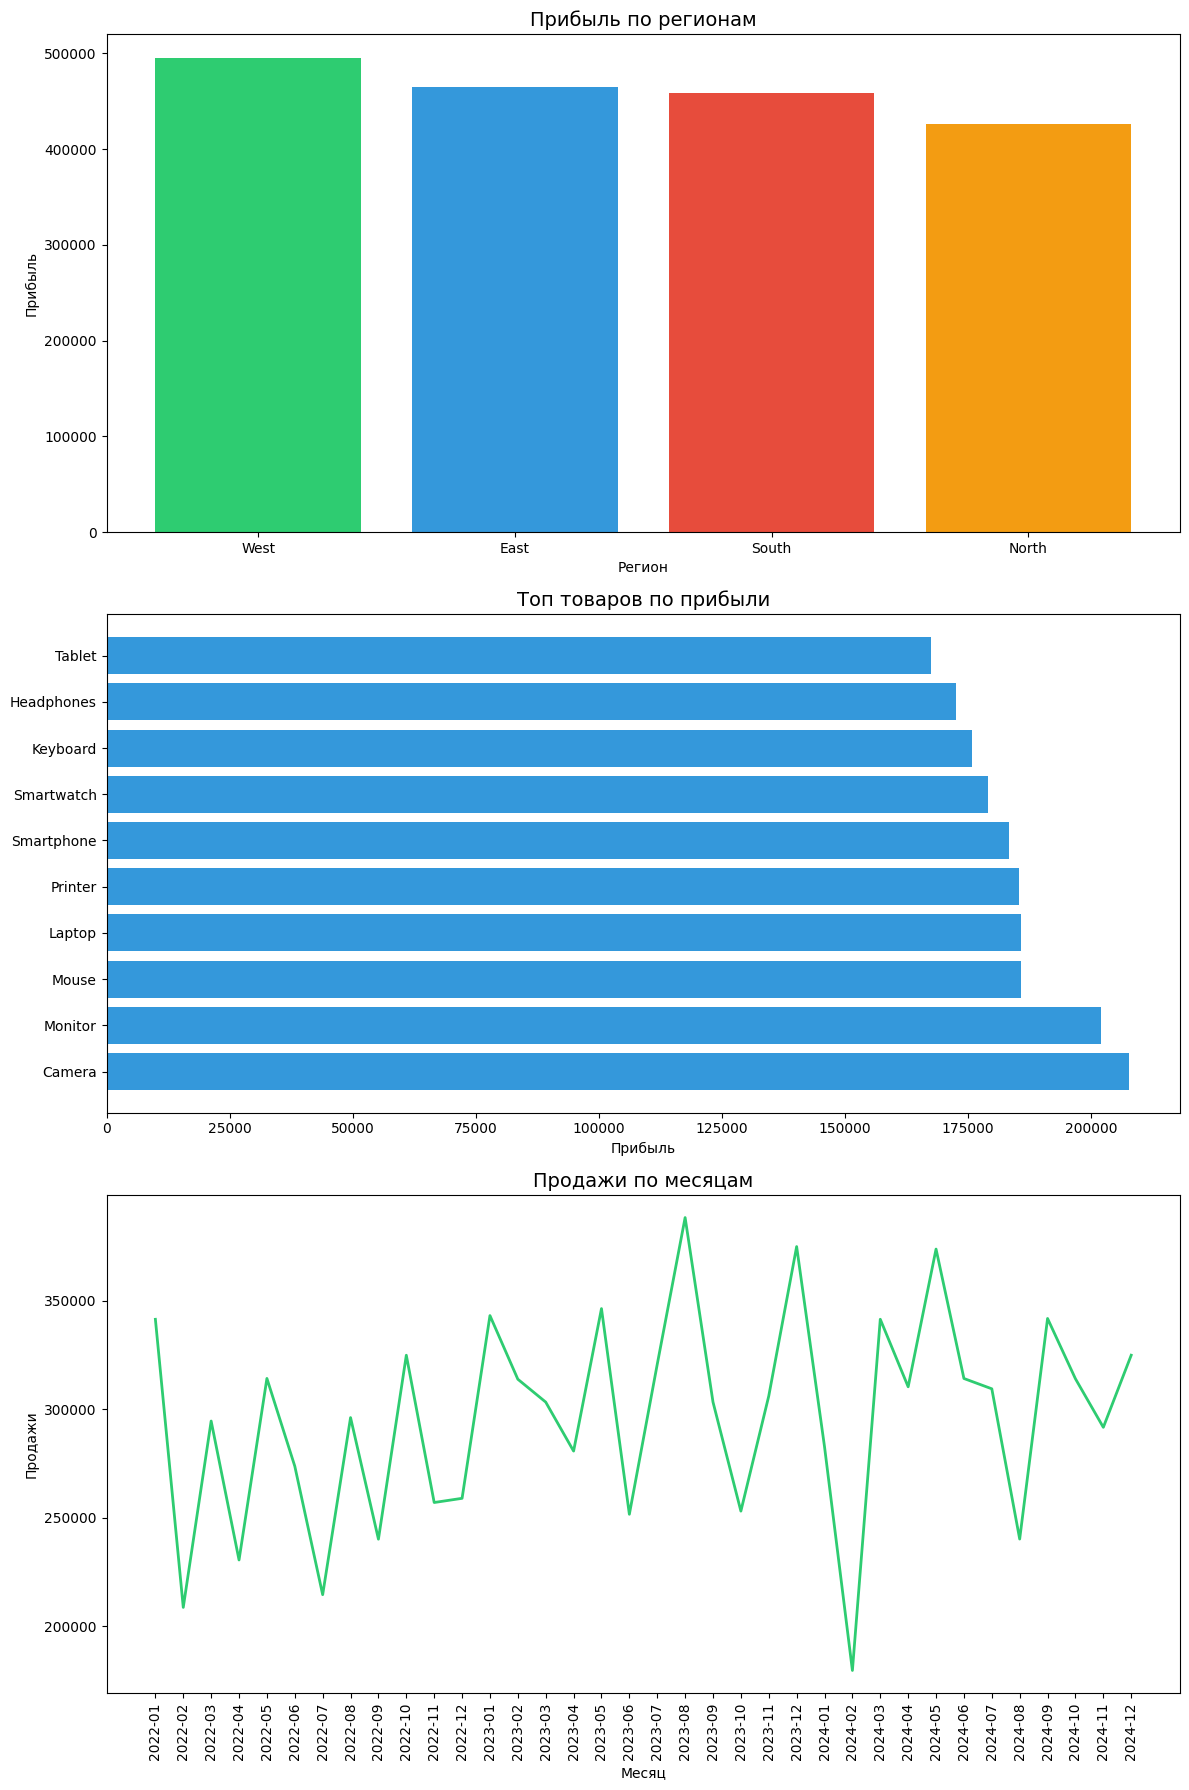

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# График 1 — Прибыль по регионам
axes[0].bar(result['Region'], result['total_profit'], color=['#2ecc71','#3498db','#e74c3c','#f39c12'])
axes[0].set_title('Прибыль по регионам', fontsize=14)
axes[0].set_xlabel('Регион')
axes[0].set_ylabel('Прибыль')

# График 2 — Топ товаров по прибыли
axes[1].barh(result2['Product Name'], result2['total_profit'], color='#3498db')
axes[1].set_title('Топ товаров по прибыли', fontsize=14)
axes[1].set_xlabel('Прибыль')

# График 3 — Сезонность продаж
axes[2].plot(result3['month'], result3['total_sales'], color='#2ecc71', linewidth=2)
axes[2].set_title('Продажи по месяцам', fontsize=14)
axes[2].set_xlabel('Месяц')
axes[2].set_ylabel('Продажи')
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Прибыльность по категориям товаров
query = """
SELECT 
    Category,
    ROUND(SUM(Profit), 2) as total_profit,
    ROUND(SUM(Sales), 2) as total_sales,
    ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) as profit_margin
FROM orders
GROUP BY Category
ORDER BY profit_margin DESC
"""

result4 = pd.read_sql(query, conn)
print(result4)

      Category  total_profit  total_sales  profit_margin
0  Electronics     923185.59    5326074.0          17.33
1  Accessories     736084.74    4247591.0          17.33
2       Office     185394.88    1094216.0          16.94


Вывод: Electronics и Accessories имеют одинаковую маржу 17.33%. Office отстаёт - 16.94%.
Рекомендация: маржинальность в норме, фокус стоит направить на увеличение объема заказов

In [9]:
# Средний чек и средняя прибыль с заказа по регионам
query = """
SELECT 
    Region,
    ROUND(AVG(Sales), 2) as avg_sales,
    ROUND(AVG(Profit), 2) as avg_profit,
    ROUND(AVG(Quantity), 2) as avg_quantity
FROM orders
GROUP BY Region
ORDER BY avg_profit DESC
"""

result5 = pd.read_sql(query, conn)
print(result5)

  Region  avg_sales  avg_profit  avg_quantity
0   West    3167.54      551.62          5.00
1   East    3106.98      539.94          5.00
2  South    3011.95      518.80          4.94
3  North    2900.67      496.87          4.79


Вывод: West лидирует по среднему чеку прибыли с заказа.
Рекомендация: изучить почему в North меньше товаров в заказе

In [10]:
# Какой товар самый прибыльный в каждом регионе
query = """
SELECT 
    Region,
    [Product Name],
    ROUND(SUM(Profit), 2) as total_profit
FROM orders
GROUP BY Region, [Product Name]
ORDER BY total_profit DESC
"""

result6 = pd.read_sql(query, conn)

# Берём топ 1 товар по каждому региону через Python
result6 = result6.groupby('Region').first().reset_index()
print(result6)

  Region Product Name  total_profit
0   East   Smartphone      55295.27
1  North      Monitor      52481.85
2  South       Camera      61837.30
3   West      Monitor      62198.09


Вывод: в каждом регионе свой лидер: West и North — Monitor, South — Camera, East — Smartphone.
Рекомендация: адаптировать рекламу под регион — продвигать тот товар который уже лидирует.